In [1]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/Gaming_Academic_Performance.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


### 1. Data Overview and Structure
Let's start by getting a general overview of the dataset, including data types, non-null values, and memory usage. This will help us identify any immediate issues like incorrect data types or missing values.

In [2]:
# Display concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


### 2. Descriptive Statistics
Next, let's look at the descriptive statistics for numerical columns to understand the central tendency, dispersion, and shape of the distribution.

In [3]:
# Display descriptive statistics for numerical columns
display(df.describe())

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


### 3. Missing Values
It's crucial to identify and handle missing values. Let's check for the presence of any null values across all columns.

In [4]:
# Check for missing values
display(df.isnull().sum())

,0
student_id,0
age,0
gender,0
gaming_hours,0
study_hours,0
sleep_hours,0
attendance,0
gaming_genre,0
social_activity,0
device_usage,0


### 4. Unique Values in Categorical Columns
Understanding the unique categories in categorical columns like `gender`, `gaming_genre`, and `stress_level` can provide insights into the data's diversity.

In [5]:
# Check unique values for categorical columns
print("Gender unique values:", df['gender'].unique())
print("Gaming Genre unique values:", df['gaming_genre'].unique())
print("Stress Level unique values:", df['stress_level'].unique())

Gender unique values: ['Male' 'Female' 'Other']
Gaming Genre unique values: ['FPS' 'Casual' 'RPG']
Stress Level unique values: ['Low' 'Medium' 'High']


### 5. Data Cleaning: Addressing Anomalies
Based on the descriptive statistics, we'll address the following anomalies:
- Cap `grades` at a maximum of 100.
- Set `addiction_score` to a minimum of 0.

In [6]:
# Cap grades at 100
df['grades'] = df['grades'].apply(lambda x: min(x, 100))

# Set minimum addiction_score to 0
df['addiction_score'] = df['addiction_score'].apply(lambda x: max(x, 0))

print("Data anomalies addressed. Reviewing descriptive statistics after cleaning:")
display(df[['grades', 'addiction_score']].describe())

Data anomalies addressed. Reviewing descriptive statistics after cleaning:


,grades,addiction_score
count,8000.000000,8000.000000
mean,66.080416,9.922191
std,22.252691,5.006251
min,0.000000,0.000000
25%,49.879843,5.920000
50%,67.070000,10.005000
75%,83.992223,13.860000
max,100.000000,23.160000


### 6. Defining and Calculating Key Performance Indicators (KPIs)
Based on the cleaned data, let's define and calculate the following KPIs:

#### KPI 1: Academic Pass Rate
We'll define 'passing' as a grade of 60 or higher. This KPI measures the overall academic success rate in the dataset.

In [7]:
# Calculate Academic Pass Rate (Grades >= 60)
pass_threshold = 60
academic_pass_rate = (df['grades'] >= pass_threshold).mean() * 100
print(f"Academic Pass Rate (Grades >= {pass_threshold}): {academic_pass_rate:.2f}%")

Academic Pass Rate (Grades >= 60): 60.86%


#### KPI 2: Average Grade by Gaming Genre
This KPI helps us understand if the type of game played has an impact on academic performance.

In [8]:
# Calculate Average Grade by Gaming Genre
average_grade_by_genre = df.groupby('gaming_genre')['grades'].mean().sort_values(ascending=False)
print("\nAverage Grade by Gaming Genre:")
display(average_grade_by_genre)


Average Grade by Gaming Genre:


,grades
gaming_genre,
Casual,66.298099
FPS,66.065763
RPG,65.882399


#### KPI 3: Correlation between Gaming Hours and Grades
This KPI quantifies the linear relationship between the time students spend gaming and their academic grades.

In [9]:
# Calculate Correlation between Gaming Hours and Grades
correlation_gaming_grades = df['gaming_hours'].corr(df['grades'])
print(f"\nCorrelation between Gaming Hours and Grades: {correlation_gaming_grades:.2f}")


Correlation between Gaming Hours and Grades: -0.55


#### KPI 4: Average Grades by Stress Level
This KPI investigates the relationship between a student's reported stress level and their academic grades.

In [10]:
# Calculate Average Grades by Stress Level
average_grade_by_stress = df.groupby('stress_level')['grades'].mean().reindex(['Low', 'Medium', 'High'])
print("\nAverage Grades by Stress Level:")
display(average_grade_by_stress)


Average Grades by Stress Level:


,grades
stress_level,
Low,50.502336
Medium,72.620790
High,80.886068


#### KPI 5: Average Grades by Study Hours Bracket
This KPI categorizes students by their study hours to observe the academic performance across different study commitments.

In [11]:
# Create study hour brackets for better analysis
df['study_hours_bracket'] = pd.cut(df['study_hours'], bins=[0, 3, 6, 10], labels=['Low (0-3h)', 'Medium (3-6h)', 'High (6-10h)'], right=False)

# Calculate Average Grades by Study Hours Bracket
average_grade_by_study_bracket = df.groupby('study_hours_bracket')['grades'].mean().sort_values(ascending=False)
print("\nAverage Grades by Study Hours Bracket:")
display(average_grade_by_study_bracket)


Average Grades by Study Hours Bracket:


/tmp/ipykernel_4475/3301587099.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_grade_by_study_bracket = df.groupby('study_hours_bracket')['grades'].mean().sort_values(ascending=False)


,grades
study_hours_bracket,
High (6-10h),82.263168
Medium (3-6h),58.884610
Low (0-3h),44.886027


### 7. Deep-Dive Analysis: Gaming Hours vs. Grades
Let's visualize the relationship between `gaming_hours` and `grades` to understand the moderate negative correlation observed in KPI 3. A scatter plot with a regression line will help illustrate this trend.

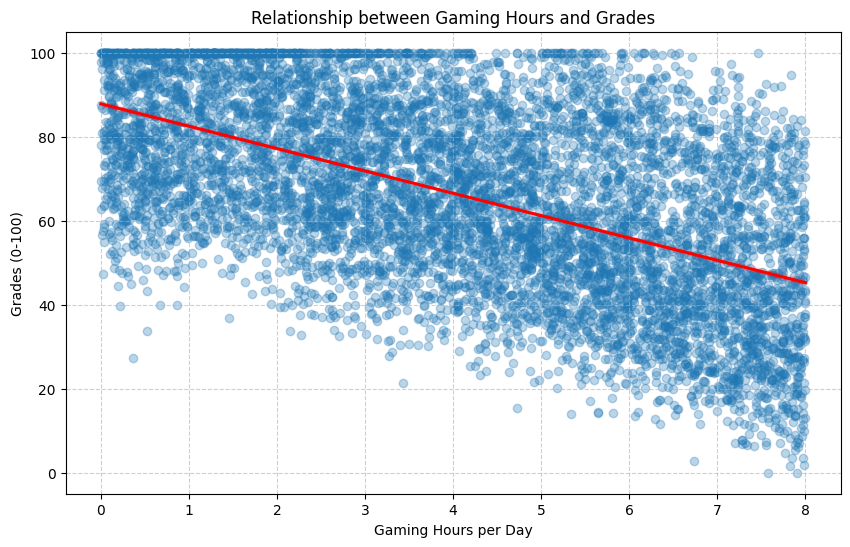

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.regplot(x='gaming_hours', y='grades', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship between Gaming Hours and Grades')
plt.xlabel('Gaming Hours per Day')
plt.ylabel('Grades (0-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 8. Deep-Dive Analysis: Stress Level vs. Grades
Let's visualize the average grades across different stress levels to understand the pattern observed in KPI 4.

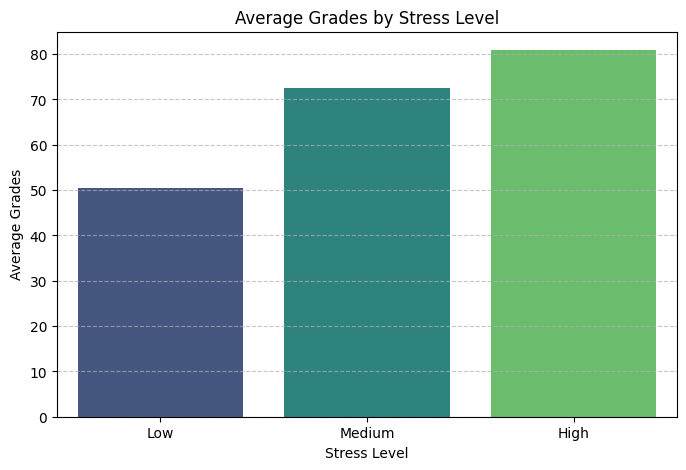

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(x=average_grade_by_stress.index, y=average_grade_by_stress.values, palette='viridis', hue=average_grade_by_stress.index, legend=False)
plt.title('Average Grades by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Average Grades')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 7. Deep-Dive Analysis: Gaming Hours vs. Grades
Let's visualize the relationship between `gaming_hours` and `grades` to understand the moderate negative correlation observed in KPI 3. A scatter plot with a regression line will help illustrate this trend.

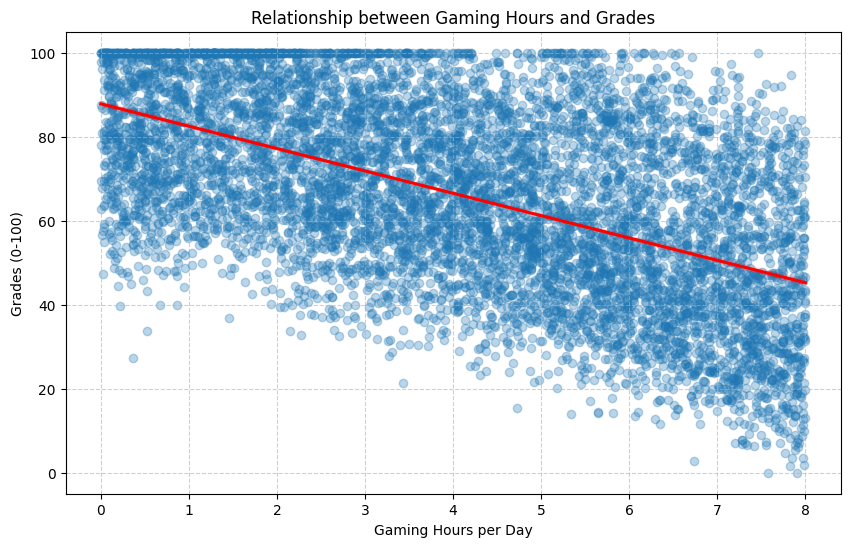

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.regplot(x='gaming_hours', y='grades', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship between Gaming Hours and Grades')
plt.xlabel('Gaming Hours per Day')
plt.ylabel('Grades (0-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 7. Deep-Dive Analysis: Gaming Hours vs. Grades
Let's visualize the relationship between `gaming_hours` and `grades` to understand the moderate negative correlation observed in KPI 3. A scatter plot with a regression line will help illustrate this trend.

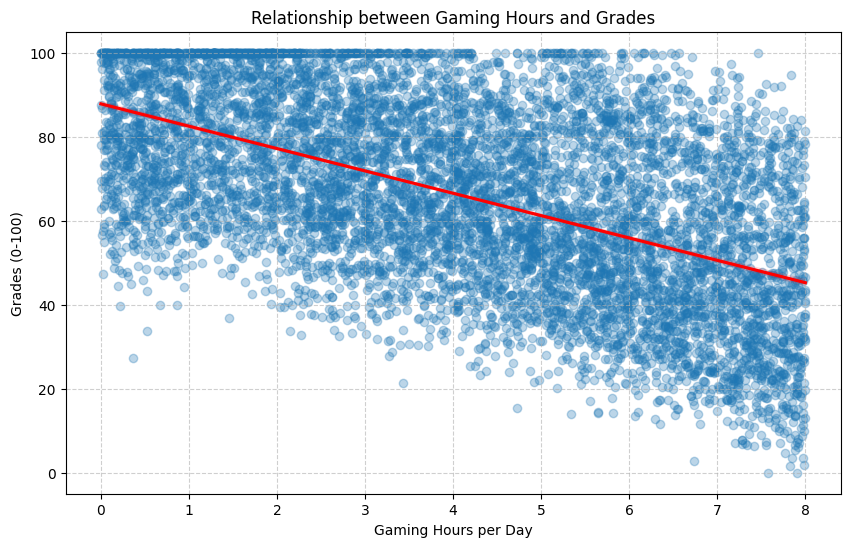

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.regplot(x='gaming_hours', y='grades', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship between Gaming Hours and Grades')
plt.xlabel('Gaming Hours per Day')
plt.ylabel('Grades (0-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()